# **PFC Self-Administration**
### *A peri-event temporal analysis of excitatory and inhibitory neural activity*

<br>

*Written by*: Joshua Boquiren

[![](https://img.shields.io/badge/@thejoshbq-grey?style=for-the-badge&logo=github)](https://github.com/thejoshbq)
[![](https://img.shields.io/badge/@thejoshbq-grey?style=for-the-badge&logo=X)](https://x.com/thejoshbq)
[![](https://img.shields.io/badge/Otis_Lab-grey?style=for-the-badge)](https://www.otis-lab.org/)

## Data Compilation & EDA

### Initial imports

<u><i>Requirements:</u></i>
- `pynapse`
- `os`

In [51]:
import os

from pynapse.config.events import LEGACY_HER
from pynapse.analysis.preprocessing.epoch.pipelines import *
from pynapse.analysis.peri_event import *

### Compile Data Into Populations

In [2]:
def create_population(dir: str):
    sample_names = [s for s in os.listdir(dir) if os.path.isdir(os.path.join(dir, s))]
    samples = []
    for s in sample_names:
        sample_dir = os.path.join(dir, s)
        FOVs = [f for f in os.listdir(sample_dir) if os.path.isdir(os.path.join(sample_dir, f))]
        for f in FOVs:
            FOV_dir = os.path.join(sample_dir, f)
            mat_files = [os.path.join(FOV_dir, m) for m in os.listdir(FOV_dir) if
                         m.endswith(".mat") and "popevents" not in m]
            npy_files = [os.path.join(FOV_dir, n) for n in os.listdir(FOV_dir) if
                         n.endswith(".npy") and "extracted" in n]
            try:
                sample = Sample(
                    event_data=mat_files,
                    signal_data=npy_files,
                    name=s,
                    fps=30,
                    frame_averaging=4,
                    frame_correction=False,
                    correction_file=None,
                    event_dict=LEGACY_HER
                )
                samples.append(sample)
            except Exception as e:
                print(f"  Sample {s} failed ({e}); skipping")
                continue
    if len(samples) == 0:
        return None
    population = Population(name=dir, samples=samples)
    population_tensor = PopulationEventTensor(
        population,
        event_id=[22, 222],
        pre_event=10,
        post_event=11.6,
        min_trials=3,
        buffer_ms=1000,
        trace_preprocess=None,
        window_preprocess=OTIS_PIPE,
    )
    event_windows = population_tensor.get_event_windows()
    if len(event_windows) == 0:
        return None
    processed_neurons = []
    for sample_tensor in event_windows:
        if sample_tensor.shape[0] == 0:  # no valid trials
            continue
        mean_per_sample = np.nanmean(sample_tensor, axis=0)
        processed_neurons.append(mean_per_sample)
    if not processed_neurons:
        return None
    all_neurons = np.vstack(processed_neurons)
    return all_neurons

In [3]:
data_dir = "./data"
data = {}
for population in sorted(os.listdir(data_dir)):
    if not os.path.isdir(os.path.join(data_dir, population)):
        continue
    if population.startswith('.'):
        continue
    population_tensor = create_population(os.path.join(data_dir, population))
    if population_tensor is not None:
        data[population] = population_tensor

/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: Deprecation

/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: Deprecation

/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: Deprecation

/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: Deprecation

/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: Deprecation

  Sample CTL1 failed (Event log or signal recording is empty.); skipping


/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: Deprecation

/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: Deprecation

/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: Deprecation

/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: DeprecationWarning: DEPRECATED: Use only for compatibility with older versions of the library.
  self._raw_data = self._compile_mat_files(source)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:86: DeprecationWarning: DEPRECATED: Use of MATLAB-produced event logs for the 'event_log' parameter is deprecated and will be removed in a future version.
  event_log = self._load_mat_file(file)
/home/otis-lab/Desktop/pynapse/pynapse/core/io/behavior.py:50: Deprecation

### Peri-Event Population Response Averaged Across Trials and Neurons

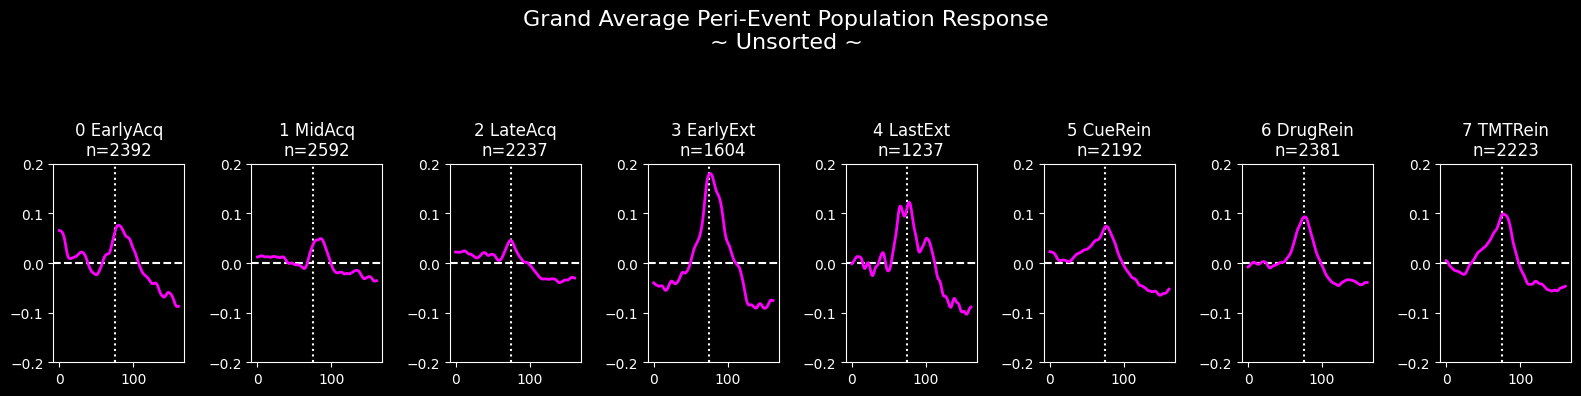

In [73]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def plot_perievent_population_grand_avg_response(data: dict):
    plt.style.use('dark_background')
    fig, axs = plt.subplots(1, len(data.items()), figsize=(16, 4))
    for col, population_name in enumerate(data):
        population_response = data.get(population_name).copy()
        grand_avg = np.nanmean(population_response, axis=0)
        event_frame = 75
        axs[col].axhline(0, color="white", linestyle="--")
        axs[col].axvline(event_frame, color="white", linestyle=":")
        axs[col].set_ylim(-0.2, 0.2)
        axs[col].plot(grand_avg, linewidth=2, color="magenta")
        axs[col].set_title(f"{population_name}\nn={data.get(population_name).shape[0]}")
    plt.suptitle("Grand Average Peri-Event Population Response\n~ Unsorted ~\n\n", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_perievent_population_grand_avg_response(data)

### Trial-Averaged Peri-Event Population Response

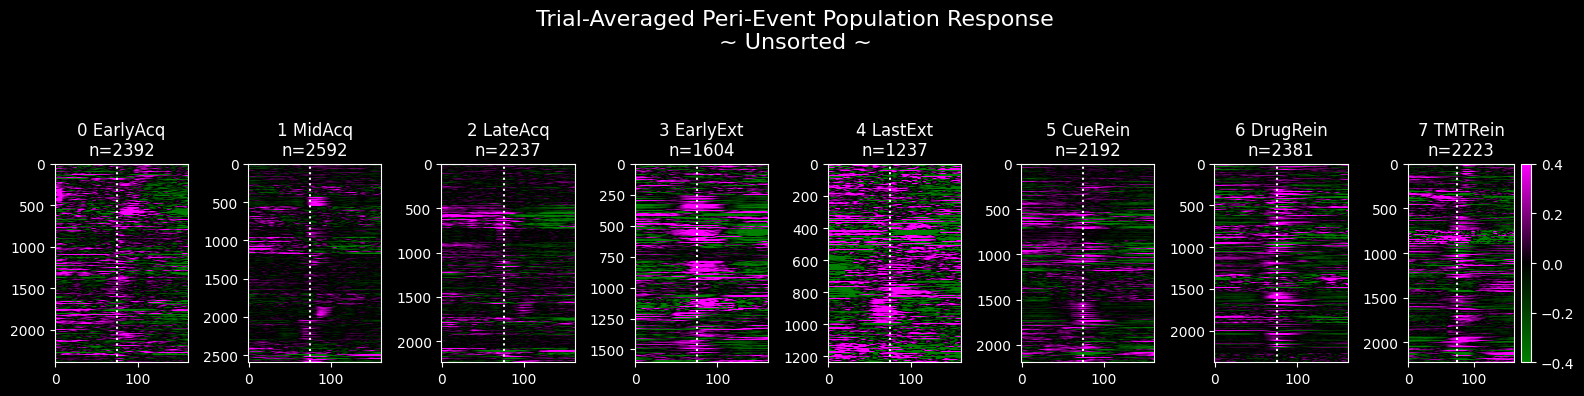

In [74]:
def plot_perievent_trial_mean(data: dict, sort: str = None):
    plt.style.use('dark_background')
    fig, axs = plt.subplots(1, len(data.items()), figsize=(16, 4))
    for col, population_name in enumerate(data):
        population_response = data.get(population_name).copy()
        event_frame = 75
        custom_cmap = LinearSegmentedColormap.from_list("GreenBlackMagenta", ["green", "black", "magenta"])
        if sort:
            if sort.lower() == "post_event_earliest_response_peaks":
                post_slice = population_response[:, event_frame:]
                peak_frames_rel = np.argmax(post_slice, axis=1)
                sort_idx = np.argsort(peak_frames_rel)
                subtitle = "Sorted by earliest response peaks"
            elif sort.lower() == "post_event_earliest_response_troughs":
                post_slice = population_response[:, event_frame:]
                peak_frames_rel = np.argmin(post_slice, axis=1)
                sort_idx = np.argsort(peak_frames_rel)
                subtitle = "Sorted by earliest response troughs"
            else:
                raise ValueError(f"Sort method '{sort}' unavailable.")
            im = axs[col].imshow(population_response[sort_idx], aspect='auto', cmap=custom_cmap, vmin=-0.4, vmax=0.4, interpolation='nearest')
        else:
            subtitle = "Unsorted"
            im = axs[col].imshow(population_response, aspect='auto', cmap=custom_cmap, vmin=-0.4, vmax=0.4, interpolation='nearest')
        axs[col].axhline(0, color="white", linestyle="--")
        axs[col].axvline(event_frame, color="white", linestyle=":")
        axs[col].set_title(f"{population_name}\nn={data.get(population_name).shape[0]}")
        if col == (len(data) - 1):
            fig.colorbar(im, ax=axs[col])
    plt.suptitle(f"Trial-Averaged Peri-Event Population Response\n~ {subtitle} ~\n\n", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_perievent_trial_mean(data=data)

## Post-Event Response Analysis

### Trial-Averaged Peri-Event Population Response

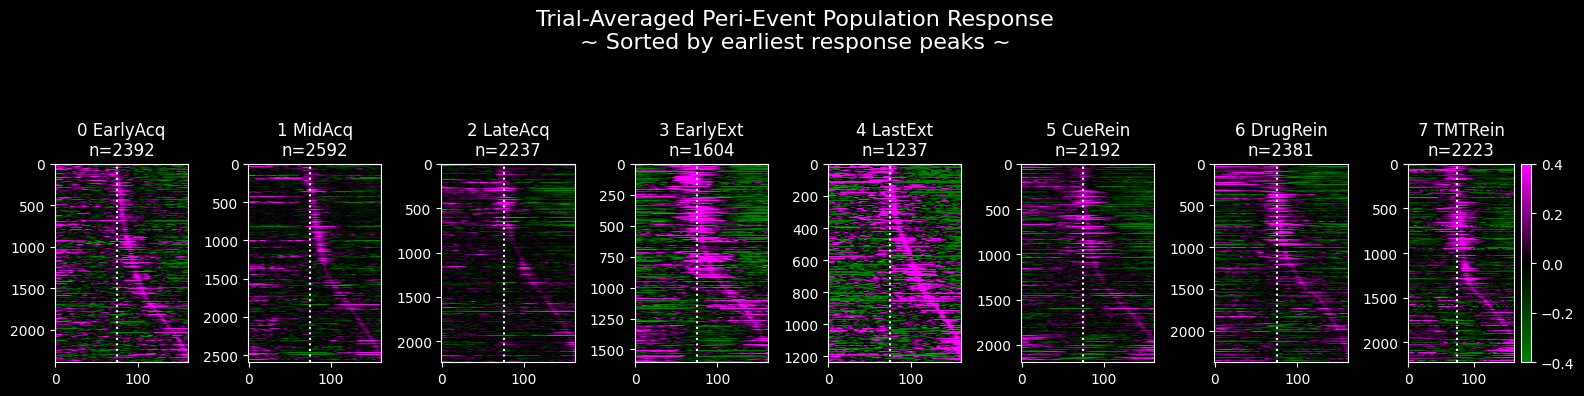

In [75]:
plot_perievent_trial_mean(data=data, sort="post_event_earliest_response_peaks")

### Post-Event Response KDE

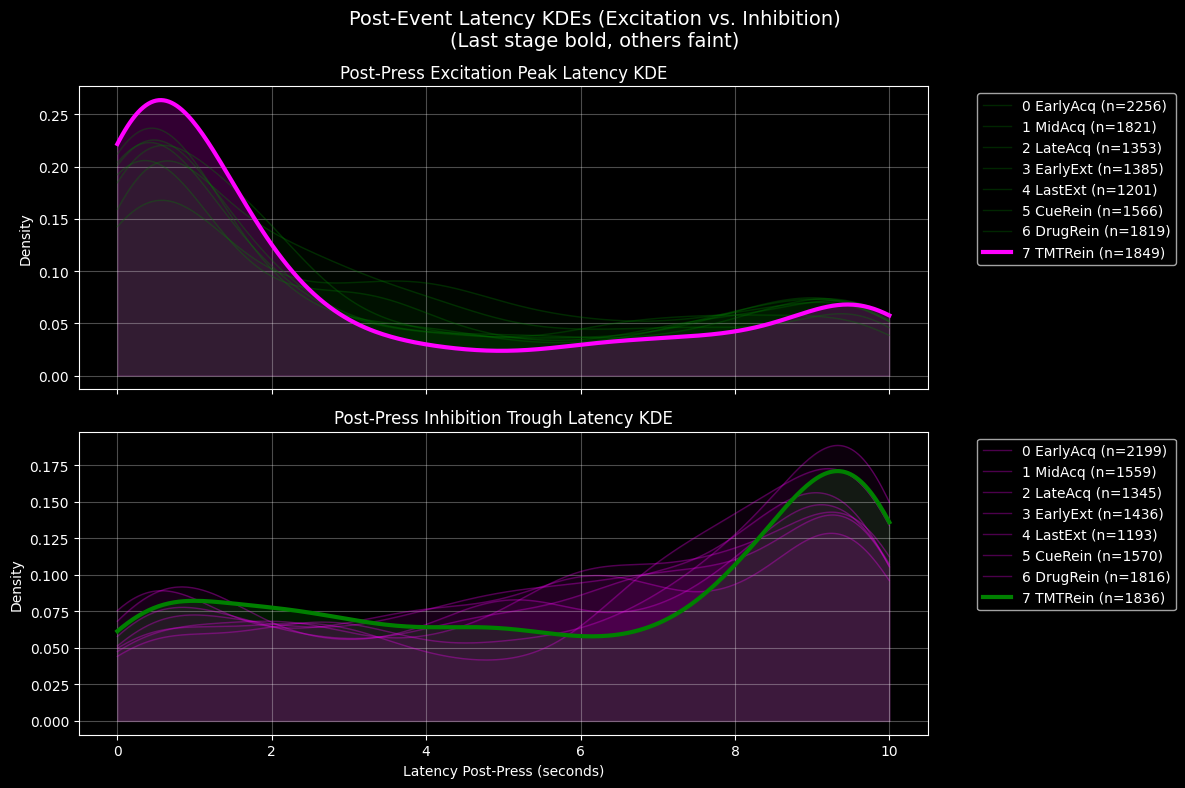

In [80]:
from scipy.stats import gaussian_kde

def plot_post_event_kde(population_data: dict):
    """
    Plot overlaid KDEs for post-press peak (excitation) and trough (inhibition) latencies.
    - Top subplot: Excitation peak latencies (all stages overlaid, current bold red, others faint blue)
    - Bottom subplot: Inhibition trough latencies (current bold blue, others faint red)
    - Quantifies timing precision—left/narrow = faster synchrony (rein exc red sharp).
    """
    n_pops = len(population_data)
    stages = sorted(population_data.keys())
    
    plt.style.use('dark_background')
    fig, (ax_exc, ax_inh) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    event_frame = 75
    fps = 7.5
    post_seconds = 10.0
    
    # Pre-compute KDE data
    exc_kde_data = {}
    inh_kde_data = {}
    for stage_name, data in population_data.items():
        post_slice = data[:, event_frame:event_frame + int(post_seconds * fps)]
        
        # Excitation peaks
        peak_frames_rel = np.argmax(post_slice, axis=1)
        peak_times_s = peak_frames_rel / fps
        exc_responsive = np.max(post_slice, axis=1) > 0.1
        exc_kde_data[stage_name] = peak_times_s[exc_responsive]
        
        # Inhibition troughs
        trough_frames_rel = np.argmin(post_slice, axis=1)
        trough_times_s = trough_frames_rel / fps
        inh_responsive = np.min(post_slice, axis=1) < -0.1
        inh_kde_data[stage_name] = trough_times_s[inh_responsive]
    
    # Plot excitation KDE (top)
    for stage_name in stages:
        times = exc_kde_data[stage_name]
        if len(times) == 0:
            continue
        kde = gaussian_kde(times)
        x = np.linspace(0, post_seconds, 300)
        y = kde(x)
        color = 'magenta' if stage_name == stages[-1] else 'green'  # Last stage bold red, others faint blue
        alpha = 1.0 if stage_name == stages[-1] else 0.3
        linewidth = 3 if stage_name == stages[-1] else 1
        ax_exc.plot(x, y, color=color, linewidth=linewidth, alpha=alpha,
                    label=f"{stage_name} (n={len(times)})")
        ax_exc.fill_between(x, y, alpha=0.2 if stage_name == stages[-1] else 0.05, color=color)
    ax_exc.set_ylabel("Density")
    ax_exc.set_title("Post-Press Excitation Peak Latency KDE")
    ax_exc.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax_exc.grid(True, alpha=0.3)
    
    # Plot inhibition KDE (bottom)
    for stage_name in stages:
        times = inh_kde_data[stage_name]
        if len(times) == 0:
            continue
        kde = gaussian_kde(times)
        x = np.linspace(0, post_seconds, 300)
        y = kde(x)
        color = 'green' if stage_name == stages[-1] else 'magenta'  # Last stage bold blue, others faint red
        alpha = 1.0 if stage_name == stages[-1] else 0.3
        linewidth = 3 if stage_name == stages[-1] else 1
        ax_inh.plot(x, y, color=color, linewidth=linewidth, alpha=alpha,
                    label=f"{stage_name} (n={len(times)})")
        ax_inh.fill_between(x, y, alpha=0.2 if stage_name == stages[-1] else 0.05, color=color)
    ax_inh.set_xlabel("Latency Post-Press (seconds)")
    ax_inh.set_ylabel("Density")
    ax_inh.set_title("Post-Press Inhibition Trough Latency KDE")
    ax_inh.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax_inh.grid(True, alpha=0.3)
    
    plt.suptitle("Post-Event Latency KDEs (Excitation vs. Inhibition)\n"
                 "(Last stage bold, others faint)", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_post_event_kde(data)

###